<a href="https://colab.research.google.com/github/zhilyaevaviktorija/machine_learning/blob/main/lectures/Lecture_3_(11_02_26)_%22feature_engineering_basic_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Пример отзыва: "Отличный товар! Очень отличный качество."
from sklearn.feature_extraction.text import CountVectorizer

texts = ["Отличный товар! Очень отличный качество."]
vectorizer = CountVectorizer(vocabulary=['отличный', 'ужасный', 'дорого'])
X = vectorizer.fit_transform(texts)

# Получаем:
# x₁ ("отличный") = 2 (слово встречается 2 раза)
# x₂ ("ужасный") = 0 (слово не встречается)
# x₃ ("дорого") = 0 (слово не встречается)
print(X.toarray())  # [[2 0 0]]

[[2 0 0]]


---

In [3]:
# Загружаем реальный учебный датасет
from sklearn.datasets import fetch_20newsgroups

newsgroups = fetch_20newsgroups(subset='train',
                                categories=['sci.space', 'rec.sport.baseball'],
                                shuffle=True,
                                random_state=42,
                                remove=('headers', 'footers', 'quotes'))

# Берем 5 документов для примера
data = []
for i in range(5):
    data.append({
        'text': newsgroups.data[i],
        'category': newsgroups.target_names[newsgroups.target[i]]
    })

data

[{'text': "I've been saying this for quite some time, but being absent from the\nnet for a while I figured I'd stick my neck out a bit...\n\nThe Royals will set the record for fewest runs scored by an AL\nteam since the inception of the DH rule.  (p.s. any ideas what this is?)\n\nThey will fall easily short of 600 runs, that's for damn sure.  I can't\nbelieve these media fools picking them to win the division (like our\nTom Gage of the Detroit News claiming Herk Robinson is some kind of\ngenius for the trades/aquisitions he's made)\n\nc-ya\n\nSean\n\n",
  'category': 'rec.sport.baseball'},
 {'text': "Sorry for asking a question that's not entirely based on the\ntechnical aspects of space, but I couldn't find the\nanswer on the FAQs !\n\nI'm currently in the UK, which makes seeing a Space Shuttle\nlaunch a little difficult.....\n\nHowever, I have been selected to be an exchange student\nat Louisiana State Uni. from August, and I am absolutely\ndetermined to get to see a Space Shuttle la

In [4]:
# Создаем 3 фичи для каждого документа
import re

for doc in data:
    text = doc['text']

    # Фича 1: Длина текста
    doc['length'] = len(text)

    # Фича 2: Есть ли цифры
    doc['has_numbers'] = 1 if re.search(r'\d', text) else 0

    # Фича 3: Есть ли вопрос
    doc['has_question'] = 1 if '?' in text else 0

data

[{'text': "I've been saying this for quite some time, but being absent from the\nnet for a while I figured I'd stick my neck out a bit...\n\nThe Royals will set the record for fewest runs scored by an AL\nteam since the inception of the DH rule.  (p.s. any ideas what this is?)\n\nThey will fall easily short of 600 runs, that's for damn sure.  I can't\nbelieve these media fools picking them to win the division (like our\nTom Gage of the Detroit News claiming Herk Robinson is some kind of\ngenius for the trades/aquisitions he's made)\n\nc-ya\n\nSean\n\n",
  'category': 'rec.sport.baseball',
  'length': 531,
  'has_numbers': 1,
  'has_question': 1},
 {'text': "Sorry for asking a question that's not entirely based on the\ntechnical aspects of space, but I couldn't find the\nanswer on the FAQs !\n\nI'm currently in the UK, which makes seeing a Space Shuttle\nlaunch a little difficult.....\n\nHowever, I have been selected to be an exchange student\nat Louisiana State Uni. from August, and I 

In [5]:
# Выводим фичи для каждого документа
for i, doc in enumerate(data):
    print(f"Документ {i+1} ({doc['category']}):")
    print(f"  Длина: {doc['length']} символов")
    print(f"  Есть цифры: {'Да' if doc['has_numbers'] else 'Нет'}")
    print(f"  Есть вопрос: {'Да' if doc['has_question'] else 'Нет'}")
    print()

Документ 1 (rec.sport.baseball):
  Длина: 531 символов
  Есть цифры: Да
  Есть вопрос: Да

Документ 2 (sci.space):
  Длина: 769 символов
  Есть цифры: Нет
  Есть вопрос: Нет

Документ 3 (rec.sport.baseball):
  Длина: 200 символов
  Есть цифры: Да
  Есть вопрос: Нет

Документ 4 (sci.space):
  Длина: 745 символов
  Есть цифры: Да
  Есть вопрос: Нет

Документ 5 (rec.sport.baseball):
  Длина: 749 символов
  Есть цифры: Нет
  Есть вопрос: Нет



---

In [6]:
import re
from textblob import TextBlob

tweets = [
    "Just launched our new product! 🚀 So excited for this journey! #startup",
    "The customer service at @SomeCompany is terrible 😡 Waited 2 hours on hold",
    "Loving the new update! The UI is 10x better now 👏",
    "Missed my flight again... 3rd time this year ✈️😭",
    "Just ran 5km in 28 minutes! New personal record 🏃‍♂️💨"
]

print("Твиты для анализа:")
for i, tweet in enumerate(tweets, 1):
    print(f"{i}. {tweet}")
print()

Твиты для анализа:
1. Just launched our new product! 🚀 So excited for this journey! #startup
2. The customer service at @SomeCompany is terrible 😡 Waited 2 hours on hold
3. Loving the new update! The UI is 10x better now 👏
4. Missed my flight again... 3rd time this year ✈️😭
5. Just ran 5km in 28 minutes! New personal record 🏃‍♂️💨



# ЗАДАНИЕ 1: ПОИСК ЭМОДЗИ

In [7]:
# Изучите пример регулярного выражения для поиска эмодзи ниже,
# затем выполните задание в своей тетрадке

def find_emojis(text):
    """Находит все эмодзи в тексте"""
    # ВАЖНО: Эта регулярка ищет эмодзи по диапазонам Unicode
    emoji_pattern = re.compile(
        "["
        "\U0001F600-\U0001F64F"  # эмоции
        "\U0001F300-\U0001F5FF"  # символы
        "\U0001F680-\U0001F6FF"  # транспорт
        "]+",
        flags=re.UNICODE
    )
    return emoji_pattern.findall(text)

# Пример работы функции:
example_tweet = "Just launched our new product! 🚀 So excited for this journey! #startup"
emojis_found = find_emojis(example_tweet)
print(f"Пример поиска эмодзи:")
print(f"Текст: '{example_tweet}'")
print(f"Найдены эмодзи: {emojis_found}")
print()

Пример поиска эмодзи:
Текст: 'Just launched our new product! 🚀 So excited for this journey! #startup'
Найдены эмодзи: ['🚀']



In [22]:
# ВАШЕ ЗАДАНИЕ:
# 1. Создайте список features = []
# 2. Для каждого твита из tweets:
#    - Найдите все эмодзи
#    - Добавьте в features словарь с ключами:
#        'emojis': список найденных эмодзи
#        'emoji_count': количество эмодзи
# 3. Выведите результат

# Создаем список features
features = []

# Для каждого твита находим все эмодзи и добавляем в словарь features
for tweet in tweets:
    emojis = find_emojis(tweet)
    feature_dict = {
        'emojis': emojis,
        'emoji_count': len(emojis)
    }
    features.append(feature_dict)

# Выводим результат
print(f"Результаты поиска эмодзи:")
for i, (tweet, feature) in enumerate(zip(tweets, features), 1):
  print(f"\nТвит {i}: '{tweet}'")
  print(f"Найдены эмодзи: {feature['emojis']}")
  print(f"Количество эмодзи: {feature['emoji_count']}")
  print()

Результаты поиска эмодзи:

Твит 1: 'Just launched our new product! 🚀 So excited for this journey! #startup'
Найдены эмодзи: ['🚀']
Количество эмодзи: 1


Твит 2: 'The customer service at @SomeCompany is terrible 😡 Waited 2 hours on hold'
Найдены эмодзи: ['😡']
Количество эмодзи: 1


Твит 3: 'Loving the new update! The UI is 10x better now 👏'
Найдены эмодзи: ['👏']
Количество эмодзи: 1


Твит 4: 'Missed my flight again... 3rd time this year ✈️😭'
Найдены эмодзи: ['😭']
Количество эмодзи: 1


Твит 5: 'Just ran 5km in 28 minutes! New personal record 🏃‍♂️💨'
Найдены эмодзи: ['🏃', '💨']
Количество эмодзи: 2



# ЗАДАНИЕ 2: ПОИСК ЧИСЕЛ

In [10]:
# Изучите пример регулярного выражения для поиска чисел,
# затем выполните задание в своей тетрадке

def find_numbers(text):
    """Находит все целые числа в тексте"""
    # ВАЖНО: \b означает границу слова, \d+ ищет одну или более цифр
    return re.findall(r'\b\d+\b', text)

# Пример работы функции:
example_tweet = "The customer service at @SomeCompany is terrible 😡 Waited 2 hours on hold"
numbers_found = find_numbers(example_tweet)
print(f"Пример поиска чисел:")
print(f"Текст: '{example_tweet}'")
print(f"Найдены числа: {numbers_found}")
print()

Пример поиска чисел:
Текст: 'The customer service at @SomeCompany is terrible 😡 Waited 2 hours on hold'
Найдены числа: ['2']



In [23]:
# ВАШЕ ЗАДАНИЕ:
# 1. Для каждого твита из tweets:
#    - Найдите все числа с помощью функции find_numbers()
#    - Добавьте в соответствующий словарь в features:
#        'numbers': список найденных чисел
#        'number_count': количество чисел
# 2. Выведите результат

# Создаем словарь features
features = []

# Используем функцию для поиска чисел
def find_numbers(text):
    """Находит все целые числа в тексте"""
    return re.findall(r'\b\d+\b', text)

# Для каждого твита находим числа и добавляем в словарь features
for tweet in tweets:
  numbers = find_numbers(tweet)
  feature_dict = {
      'numbers': numbers,
      'numbers_count': len(numbers)
  }
  features.append(feature_dict)

# Выводим результат
print(f"Результаты поиска чисел:")
for i, (tweet, feature) in enumerate(zip(tweets, features), 1):
  print(f"\nТвит {i}: '{tweet}'")
  print(f"Найдены числа: {feature['numbers']}")
  print(f"Количество чисел: {feature['numbers_count']}")
  print()

Результаты поиска чисел:

Твит 1: 'Just launched our new product! 🚀 So excited for this journey! #startup'
Найдены числа: []
Количество чисел: 0


Твит 2: 'The customer service at @SomeCompany is terrible 😡 Waited 2 hours on hold'
Найдены числа: ['2']
Количество чисел: 1


Твит 3: 'Loving the new update! The UI is 10x better now 👏'
Найдены числа: []
Количество чисел: 0


Твит 4: 'Missed my flight again... 3rd time this year ✈️😭'
Найдены числа: []
Количество чисел: 0


Твит 5: 'Just ran 5km in 28 minutes! New personal record 🏃‍♂️💨'
Найдены числа: ['28']
Количество чисел: 1



# ЗАДАНИЕ 3: АНАЛИЗ ТОНАЛЬНОСТИ

In [17]:
# Изучите пример использования TextBlob ниже,
# затем выполните задание в своей тетрадке

# Пример работы с TextBlob:
example_tweet = "Loving the new update! The UI is 10x better now 👏"
blob = TextBlob(example_tweet)
print(f"Пример анализа тональности:")
print(f"Текст: '{example_tweet}'")
print(f"Тональность: {blob.sentiment.polarity:.2f} (от -1 до 1)")
print(f"Субъективность: {blob.sentiment.subjectivity:.2f} (0=объективный, 1=субъективный)")
print()

Пример анализа тональности:
Текст: 'Loving the new update! The UI is 10x better now 👏'
Тональность: 0.42 (от -1 до 1)
Субъективность: 0.63 (0=объективный, 1=субъективный)



In [24]:
# ВАШЕ ЗАДАНИЕ:
# 1. Для каждого твита из tweets:
#    - Создайте объект TextBlob
#    - Добавьте в соответствующий словарь в features:
#        'sentiment': тональность (округлите до 2 знаков)
#        'subjectivity': субъективность (округлите до 2 знаков)
# 2. Определите тип тональности (положительная/отрицательная/нейтральная)
# 3. Выведите результат

# Создаем словарь features
features = []

# Создаем TextBlob
blob = TextBlob(tweet)

# Для каждого твита находим тональность и субъективность
for tweet in tweets:
  blob = TextBlob(tweet)

  # Определяем тип тональности
  polarity = blob.sentiment.polarity
  if polarity > 0.1:
    sentiment_type = "положительная"
  elif polarity < -0.1:
    sentiment_type = "отрицательная"
  else:
    sentiment_type = "нейтральная"

  # Добавляем в словарь
  feature_dict = {
      'sentiment': round(polarity, 2),                        # тональность
      'subjectivity': round(blob.sentiment.subjectivity, 2),  # субъективность
      'sentiment_type': sentiment_type                        # тип тональности
  }
  features.append(feature_dict)

# Выводим результат
print(f"Результаты анализа тональности:")
for i, (tweet, feature) in enumerate(zip(tweets, features), 1):
  print(f"\nТвит {i}: '{tweet}'")
  print(f"Тональность: {feature['sentiment']} ({feature['sentiment_type']})")
  print(f"Субъективность: {feature['subjectivity']}")
  print()

Результаты анализа тональности:

Твит 1: 'Just launched our new product! 🚀 So excited for this journey! #startup'
Тональность: 0.32 (положительная)
Субъективность: 0.6


Твит 2: 'The customer service at @SomeCompany is terrible 😡 Waited 2 hours on hold'
Тональность: -1.0 (отрицательная)
Субъективность: 1.0


Твит 3: 'Loving the new update! The UI is 10x better now 👏'
Тональность: 0.42 (положительная)
Субъективность: 0.63


Твит 4: 'Missed my flight again... 3rd time this year ✈️😭'
Тональность: 0.0 (нейтральная)
Субъективность: 0.0


Твит 5: 'Just ran 5km in 28 minutes! New personal record 🏃‍♂️💨'
Тональность: 0.07 (нейтральная)
Субъективность: 0.38



# ИТОГОВЫЙ ВЫВОД

In [31]:
# После выполнения всех заданий выведите финальную таблицу
# Пример формата:
# Твит 1: [первые 50 символов...]
#   Эмодзи: [...] (3 шт.)
#   Числа: [...] (2 шт.)
#   Тональность: 0.75 (положительная)
#   Субъективность: 0.60

import re
from textblob import TextBlob

tweets = [
    "Just launched our new product! 🚀 So excited for this journey! #startup",
    "The customer service at @SomeCompany is terrible 😡 Waited 2 hours on hold",
    "Loving the new update! The UI is 10x better now 👏",
    "Missed my flight again... 3rd time this year ✈️😭",
    "Just ran 5km in 28 minutes! New personal record 🏃‍♂️💨"
]

# Функция для поиска эмодзи
def find_emojis(text):
    """Находит все эмодзи в тексте"""
    emoji_pattern = re.compile(
        "["
        "\U0001F600-\U0001F64F"  # эмоции
        "\U0001F300-\U0001F5FF"  # символы
        "\U0001F680-\U0001F6FF"  # транспорт
        "]+",
        flags=re.UNICODE
    )
    return emoji_pattern.findall(text)

# Функция для поиска чисел
def find_numbers(text):
    """Находит все целые числа в тексте"""
    return re.findall(r'\b\d+\b', text)

# Создаем общий список
features = []

# Собираем все данные по трем фичам для каждого твита
for tweet in tweets:
    # Находим эмодзи
    emojis = find_emojis(tweet)

    # Находим числа
    numbers = find_numbers(tweet)

    # Анализируем тональность
    blob = TextBlob(tweet)
    polarity = blob.sentiment.polarity

    # Определяем тип тональности
    if polarity > 0.1:
        sentiment_type = "положительная"
    elif polarity < -0.1:
        sentiment_type = "отрицательная"
    else:
        sentiment_type = "нейтральная"

    # Собираем все данные в словарь feature
    feature_dict = {
        'emojis': emojis,
        'emoji_count': len(emojis),
        'numbers': numbers,
        'numbers_count': len(numbers),
        'sentiment': round(polarity, 2),
        'subjectivity': round(blob.sentiment.subjectivity, 2),
        'sentiment_type': sentiment_type
    }
    features.append(feature_dict)

# Выводим финальную таблицу
print("Финальные результаты анализа твитов")

for i, (tweet, feature) in enumerate(zip(tweets, features), 1):
    # Обрезаем твит до 50 символов
    tweet_final = tweet[:50] + "..." if len(tweet) > 50 else tweet

    # Выводим результат
    print(f"\nТвит {i}: {tweet_final}")
    print(f"  Эмодзи: {feature['emojis']} ({feature['emoji_count']} шт.)")
    print(f"  Числа: {feature['numbers']} ({feature['numbers_count']} шт.)")
    print(f"  Тональность: {feature['sentiment']} ({feature['sentiment_type']})")
    print(f"  Субъективность: {feature['subjectivity']:.2f}")

Финальные результаты анализа твитов

Твит 1: Just launched our new product! 🚀 So excited for th...
  Эмодзи: ['🚀'] (1 шт.)
  Числа: [] (0 шт.)
  Тональность: 0.32 (положительная)
  Субъективность: 0.60

Твит 2: The customer service at @SomeCompany is terrible 😡...
  Эмодзи: ['😡'] (1 шт.)
  Числа: ['2'] (1 шт.)
  Тональность: -1.0 (отрицательная)
  Субъективность: 1.00

Твит 3: Loving the new update! The UI is 10x better now 👏
  Эмодзи: ['👏'] (1 шт.)
  Числа: [] (0 шт.)
  Тональность: 0.42 (положительная)
  Субъективность: 0.63

Твит 4: Missed my flight again... 3rd time this year ✈️😭
  Эмодзи: ['😭'] (1 шт.)
  Числа: [] (0 шт.)
  Тональность: 0.0 (нейтральная)
  Субъективность: 0.00

Твит 5: Just ran 5km in 28 minutes! New personal record 🏃‍...
  Эмодзи: ['🏃', '💨'] (2 шт.)
  Числа: ['28'] (1 шт.)
  Тональность: 0.07 (нейтральная)
  Субъективность: 0.38


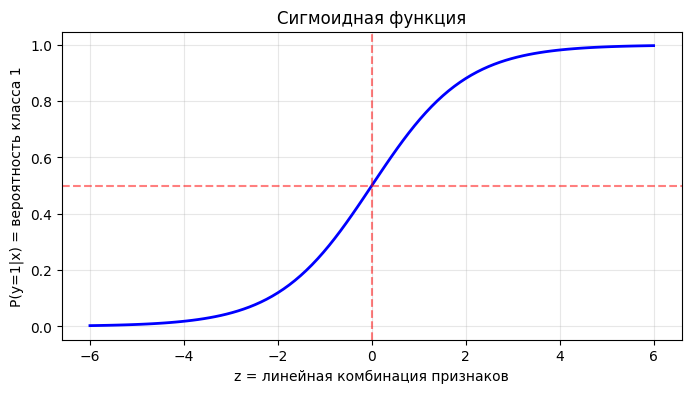

In [32]:
import numpy as np
import matplotlib.pyplot as plt

z = np.linspace(-6, 6, 100)
sigma = 1 / (1 + np.exp(-z))

plt.figure(figsize=(8, 4))
plt.plot(z, sigma, 'b-', linewidth=2)
plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.5)
plt.axvline(x=0, color='r', linestyle='--', alpha=0.5)
plt.xlabel('z = линейная комбинация признаков')
plt.ylabel('P(y=1|x) = вероятность класса 1')
plt.title('Сигмоидная функция')
plt.grid(True, alpha=0.3)
plt.show()